In [4]:
from huggingface_hub import hf_hub_download, login

In [5]:
login()

In [10]:
hf_hub_download(repo_id='Jungle15/GDP-HMM_Challenge', filename='train_HaN.zip', repo_type="dataset", local_dir='.')

train_HaN.zip:   0%|          | 0.00/17.6G [00:00<?, ?B/s]

'train_HaN.zip'

In [11]:
hf_hub_download(repo_id='Jungle15/GDP-HMM_Challenge', filename='train_Lung.zip', repo_type="dataset", local_dir='.')

train_Lung.zip:   0%|          | 0.00/21.4G [00:00<?, ?B/s]

'train_Lung.zip'

# Train

In [1]:
from pathlib import Path

code_dir = Path('/workspace/GDP-HMM_AAPMChallenge')
prj_dir = code_dir

In [2]:
import sys
sys.path.append(code_dir.as_posix()) # Need to be string
sys.path.append((code_dir/'mednext').as_posix())

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from nnunet_mednext import create_mednext_v1
import yaml
from pprint import pprint

In [7]:
%load_ext autoreload
%autoreload 2

import data_loader



In [8]:
cfig = yaml.load(open(prj_dir / 'config_files/config.yaml'), Loader=yaml.FullLoader)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
# loaders = data_loader.GetLoader(cfig = cfig['loader_params'])
# train_loader =loaders.train_dataloader()
# val_loader = loaders.val_dataloader()

In [15]:
model = create_mednext_v1( num_input_channels = cfig['model_params']['num_input_channels'],
  num_classes = cfig['model_params']['out_channels'],
  model_id = cfig['model_params']['model_id'],          # S, B, M and L are valid model ids
  kernel_size = cfig['model_params']['kernel_size'],   # 3x3x3 and 5x5x5 were tested in publication
  deep_supervision = cfig['model_params']['deep_supervision']
).to(device)

In [ ]:
# ds_cfig = {
#   'train_bs': 1,
#   'val_bs': 1,
#   'num_workers': 0,
#   'csv_root': code_dir/'meta_files/meta_data.csv',
#   'scale_dose_dict': code_dir/'meta_files/PTV_DICT.json',
#   'pat_obj_dict': code_dir/'meta_files/Pat_Obj_DICT.json',
#   'down_HU': -1000,
#   'up_HU': 1000,
#   'denom_norm_HU': 500,
#   'in_size': (96, 128, 144),
#   'out_size': (96, 128, 144),
#   'norm_oar': True,
#   'CatStructures': False,
#   'dose_div_factor': 10
# }

# from data_loader import MyDataset
# dataset = MyDataset(ds_cfig, 'train')


In [16]:
from sklearn.model_selection import train_test_split

others, test_ids = train_test_split(range(len(dataset)), test_size=0.3, random_state=1234)
train_ids, val_ids = train_test_split(others, test_size=0.3, random_state=1234)

In [17]:
from tqdm import tqdm
import numpy as np

In [21]:
optimizer = optim.Adam(model.parameters(), lr=cfig['lr'])
criterion = nn.L1Loss()
epochs = 10

In [49]:
def cal_error(pred, gt, body):
    isodose_5Gy_mask = ((gt > 5) | (pred > 5)) & (body > 0)
    isodose_ref_5Gy_mask = (gt > 5) & (body > 0)
    diff = gt - pred
    error = torch.sum(torch.abs(diff)[isodose_5Gy_mask > 0]) / torch.sum(isodose_ref_5Gy_mask)
    return error

In [54]:
save_dir = Path('/workspace/data/train_data_dict')

for epoch in range(epochs):
    model.train()

    pbar = tqdm(train_ids[60:90], f'Epoch {epoch}')

    train_loss = []
    for i in pbar:

      npz_path = save_dir/f'{i}.npz'

      data_dict = dict(np.load(npz_path))
      data_dict['data'] = torch.from_numpy(data_dict['data'])
      data_dict['label'] = torch.from_numpy(data_dict['label'])

      body_mask = data_dict['data'][:,3:4,...].bool().to(device)
      outbody_mask = ~body_mask
      ptv_mask = data_dict['data'][:,1:2, ...].bool().to(device)
      near_mask = torch.logical_and(~ptv_mask, body_mask)

      label = data_dict['label'].to(device)

      # Forward pass
      outputs = model(data_dict['data'].to(device))

      # loss = criterion(outputs, label)

      # loss = criterion(outputs[body_mask], label[body_mask])

      # loss = criterion(outputs[body_mask], label[body_mask]) + \
      #        5 * criterion(outputs[near_mask], label[near_mask])

      loss = cal_error(outputs, label, body_mask) + criterion(outputs, label) + torch.max(outputs[outbody_mask])

      # Backward pass and optimization
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      train_loss.append(loss.detach().cpu().item())
      pbar.set_postfix_str(f'Loss: {loss.item():.3f}')

    val_loss = []
    model.eval()
    for i in val_ids[:10]:
      with torch.no_grad():
          npz_path = save_dir/f'{i}.npz'
          data_dict = dict(np.load(npz_path))
          data_dict['data'] = torch.from_numpy(data_dict['data'])
          data_dict['label'] = torch.from_numpy(data_dict['label'])
    
          body_mask = data_dict['data'][:,3:4,...].bool().to(device)
          ptv_mask = data_dict['data'][:,1:2, ...].bool().to(device)
          near_mask = torch.logical_and(~ptv_mask, body_mask)
    
          label = data_dict['label'].to(device)
    
          # Forward pass
          outputs = model(data_dict['data'].to(device))
          # loss = criterion(outputs[body_mask], label[body_mask]) # + \
          #        # 5 * criterion(outputs[near_mask], label[near_mask])

          loss = cal_error(outputs, label, body_mask)
          
          val_loss.append(loss.detach().cpu().item())

    print(f'Train loss: {np.mean(train_loss):.3f}  Val loss: {np.mean(val_loss):.3f}')


Epoch 0: 100%|██████████| 30/30 [00:14<00:00,  2.05it/s, Loss: 3.648] 


Train loss: 6.283  Val loss: 1.642


Epoch 1: 100%|██████████| 30/30 [00:14<00:00,  2.07it/s, Loss: 3.035]


Train loss: 4.452  Val loss: 1.446


Epoch 2: 100%|██████████| 30/30 [00:14<00:00,  2.05it/s, Loss: 2.517]


...

Train loss: 2.724  Val loss: 1.505


Epoch 8: 100%|██████████| 30/30 [00:14<00:00,  2.11it/s, Loss: 1.692]


Train loss: 2.588  Val loss: 1.372


Epoch 9: 100%|██████████| 30/30 [00:13<00:00,  2.15it/s, Loss: 1.777]


Train loss: 2.435  Val loss: 1.450


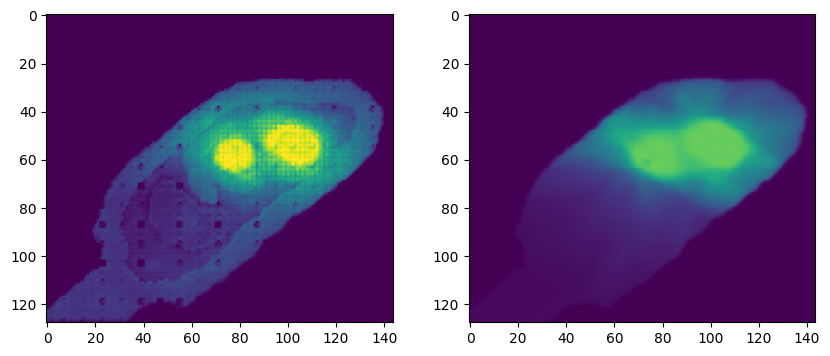

In [55]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(outputs[0,0,40].detach().cpu(), vmin=0, vmax=8)
ax[1].imshow(data_dict['label'][0,0,40], vmin=0, vmax=8)

In [38]:
ref_dose = data_dict['label'].cpu().numpy()
prediction = outputs.detach().cpu().numpy()
body = body_mask.cpu().numpy()

isodose_5Gy_mask = ((ref_dose > 5) | (prediction > 5)) & (body > 0) # the mask include the body AND the region where the dose/prediction is higher than 5Gy

isodose_ref_5Gy_mask = (ref_dose > 5) & (body > 0) # the mask include the body AND the region where the ref is higher than 5Gy

diff = ref_dose - prediction

error = np.sum(np.abs(diff)[isodose_5Gy_mask > 0]) / np.sum(isodose_ref_5Gy_mask)

In [50]:
cal_error(outputs.detach().cpu(), data_dict['label'], body_mask.cpu().numpy())

tensor(1.3662)

In [39]:
error

1.3662197851783693